In [1]:
import os
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# for data augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
'''# Corsican dataset paths
images_path = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/corsican/images"
masks_path = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/corsican/masks"

# path to save models, history and results
SAVE_DIR = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/corsican/corsican_model_unet"
os.makedirs(SAVE_DIR, exist_ok=True)'''

'# Corsican dataset paths\nimages_path = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/corsican/images"\nmasks_path = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/corsican/masks"\n\n# path to save models, history and results\nSAVE_DIR = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/corsican/corsican_model_unet"\nos.makedirs(SAVE_DIR, exist_ok=True)'

In [ ]:
'''# Boreal dataset paths
images_path = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/boreal/images"
masks_path = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/boreal/masks"

# path to save models, history and results
SAVE_DIR = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/boreal/boreal_model_unet"
os.makedirs(SAVE_DIR, exist_ok=True)'''

In [2]:
# Kaggle dataset paths
images_path = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/kaggle/images"
masks_path = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/kaggle/masks"

# path to save models, history and results
SAVE_DIR = "/mnt/c/Users/lloyd/OneDrive/Documents/UP/8vo_Semestre/ML_II/kaggle/kaggle_model_unet"
os.makedirs(SAVE_DIR, exist_ok=True)

In [5]:
'''class FireDataset(Dataset):
    def __init__(self, images_path, masks_path, transform=None):
        self.images_path = images_path
        self.masks_path = masks_path
        self.transform = transform

        self.images = sorted(os.listdir(images_path))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
      img_name = self.images[idx]

      img_path = os.path.join(self.images_path, img_name)
      mask_name = img_name.replace("_rgb", "_gt")
      mask_path = os.path.join(self.masks_path, mask_name)

      image = np.array(Image.open(img_path).convert("RGB"))
      mask = np.array(Image.open(mask_path).convert("L"))

      mask = (mask > 0).astype("float32")

      if self.transform:
          augmented = self.transform(image=image, mask=mask)
          image = augmented["image"]
          mask = augmented["mask"].unsqueeze(0)

      if image.shape[1] != 256 or image.shape[2] != 256:
          image = torch.nn.functional.interpolate(
              image.unsqueeze(0), size=(256, 256), mode="bilinear", align_corners=False
          ).squeeze(0)

      if mask.shape[1] != 256 or mask.shape[2] != 256:
          mask = torch.nn.functional.interpolate(
              mask.unsqueeze(0), size=(256, 256), mode="nearest"
          ).squeeze(0)

      return image, mask'''

'class FireDataset(Dataset):\n    def __init__(self, images_path, masks_path, transform=None):\n        self.images_path = images_path\n        self.masks_path = masks_path\n        self.transform = transform\n\n        self.images = sorted(os.listdir(images_path))\n\n    def __len__(self):\n        return len(self.images)\n\n    def __getitem__(self, idx):\n      img_name = self.images[idx]\n\n      img_path = os.path.join(self.images_path, img_name)\n      mask_name = img_name.replace("_rgb", "_gt")\n      mask_path = os.path.join(self.masks_path, mask_name)\n\n      image = np.array(Image.open(img_path).convert("RGB"))\n      mask = np.array(Image.open(mask_path).convert("L"))\n\n      mask = (mask > 0).astype("float32")\n\n      if self.transform:\n          augmented = self.transform(image=image, mask=mask)\n          image = augmented["image"]\n          mask = augmented["mask"].unsqueeze(0)\n\n      if image.shape[1] != 256 or image.shape[2] != 256:\n          image = torch.nn.f

In [ ]:
'''class FireDataset(Dataset):
    def __init__(self, images_path, masks_path, transform=None):
        self.images_path = images_path
        self.masks_path = masks_path
        self.transform = transform
        self.images = sorted(os.listdir(images_path))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.images_path, img_name)

        mask_stem = os.path.splitext(img_name)[0].replace("_rgb", "_gt")
        candidates = [f for f in os.listdir(self.masks_path) if os.path.splitext(f)[0] == mask_stem]
        if not candidates:
            raise FileNotFoundError(f"No mask found for image: {img_name}")
        mask_path = os.path.join(self.masks_path, candidates[0])

        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path).convert("L"))

        mask = (mask > 0).astype("float32")

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask  = augmented["mask"].unsqueeze(0)

        if image.shape[1] != 256 or image.shape[2] != 256:
            image = torch.nn.functional.interpolate(
                image.unsqueeze(0), size=(256, 256), mode="bilinear", align_corners=False
            ).squeeze(0)

        if mask.shape[1] != 256 or mask.shape[2] != 256:
            mask = torch.nn.functional.interpolate(
                mask.unsqueeze(0), size=(256, 256), mode="nearest"
            ).squeeze(0)

        return image, mask'''

In [18]:
class FireDataset(Dataset):
    def __init__(self, images_path, masks_path, transform=None):
        self.images_path = images_path
        self.masks_path  = masks_path
        self.transform   = transform
        self.images      = sorted(os.listdir(images_path))

        # ← Construir el mapeo imagen→máscara UNA sola vez
        mask_files = os.listdir(masks_path)
        mask_index = {os.path.splitext(f)[0]: f for f in mask_files}

        self.mask_map = {}
        for img_name in self.images:
            mask_stem = os.path.splitext(img_name)[0].replace("_rgb", "_gt")
            if mask_stem not in mask_index:
                raise FileNotFoundError(f"No mask found for image: {img_name}")
            self.mask_map[img_name] = os.path.join(masks_path, mask_index[mask_stem])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.images_path, img_name)
        mask_path = self.mask_map[img_name]  # ← lookup instantáneo, sin os.listdir

        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path).convert("L"))
        mask  = (mask > 0).astype("float32")

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask  = augmented["mask"].unsqueeze(0)

        # Estos dos bloques son redundantes si el transform ya tiene Resize(256,256)
        # pero los dejamos como seguro
        if image.shape[1] != 256 or image.shape[2] != 256:
            image = torch.nn.functional.interpolate(
                image.unsqueeze(0), size=(256, 256), mode="bilinear", align_corners=False
            ).squeeze(0)

        if mask.shape[1] != 256 or mask.shape[2] != 256:
            mask = torch.nn.functional.interpolate(
                mask.unsqueeze(0), size=(256, 256), mode="nearest"
            ).squeeze(0)

        return image, mask

In [19]:
#Data augmenattion
train_transform  = A.Compose([
    A.HorizontalFlip(p=0.5), # random flip
    A.VerticalFlip(p=0.5),
    A.Resize(256, 256), # resize
    A.HueSaturationValue(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

test_transform = val_transform

In [20]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [21]:
import torchvision.models as models

class InceptionV3Encoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        inception = models.inception_v3(pretrained=pretrained, aux_logits=True)

        # InceptionV3 is divided in blocks to extract features at different scales
        # Initial Block (conv + maxpool)
        self.block0 = nn.Sequential(
            inception.Conv2d_1a_3x3,
            inception.Conv2d_2a_3x3,
            inception.Conv2d_2b_3x3,
            nn.MaxPool2d(kernel_size=3, stride=2)
        ) # Outut: 64 channels

        # Block 1
        self.block1 = nn.Sequential(
            inception.Conv2d_3b_1x1,
            inception.Conv2d_4a_3x3,
            nn.MaxPool2d(kernel_size=3, stride=2)
        )  # Output: 192 channels

        # Block 2 (Mixed_5b, Mixed_5c, Mixed_5d)
        self.block2 = nn.Sequential(
            inception.Mixed_5b,
            inception.Mixed_5c,
            inception.Mixed_5d
        )  # Output: 288 channels

        # Block 3 (Mixed_6a, Mixed_6b, Mixed_6c, Mixed_6d, Mixed_6e)
        self.block3 = nn.Sequential(
            inception.Mixed_6a,
            inception.Mixed_6b,
            inception.Mixed_6c,
            inception.Mixed_6d,
            inception.Mixed_6e
        )  # Output: 768 channels

        # Bloque 4 (Mixed_7a, Mixed_7b, Mixed_7c)
        self.block4 = nn.Sequential(
            inception.Mixed_7a,
            inception.Mixed_7b,
            inception.Mixed_7c
        )  # Output: 2048 channels

    def forward(self, x):
        # Extract features at different levels
        x0 = self.block0(x)   # 1/2 resolution, 64 channels
        x1 = self.block1(x0)  # 1/4 resolution, 192 channels
        x2 = self.block2(x1)  # 1/8 resolution, 288 channels
        x3 = self.block3(x2)  # 1/16 resolution, 768 channels
        x4 = self.block4(x3)  # 1/32 resolution, 2048 channels

        return x0, x1, x2, x3, x4


In [22]:
import torch.nn.functional as F

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Adjust the channels accrding to the InceptionV3 outputs
        # x4: 2048 channels
        # x3: 768 channels
        # x2: 288 channels
        # x1: 192 channels
        # x0: 64 channels

        self.up1 = nn.ConvTranspose2d(2048, 768, 2, stride=2)
        self.dec1 = DoubleConv(768 + 768, 768)

        self.up2 = nn.ConvTranspose2d(768, 288, 2, stride=2)
        self.dec2 = DoubleConv(288 + 288, 288)

        self.up3 = nn.ConvTranspose2d(288, 192, 2, stride=2)
        self.dec3 = DoubleConv(192 + 192, 192)

        self.up4 = nn.ConvTranspose2d(192, 64, 2, stride=2)
        self.dec4 = DoubleConv(64 + 64, 64)

        # Upsampling  to get the original dimensions
        self.up5 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.dec5 = DoubleConv(64, 64)

        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x0, x1, x2, x3, x4):

        '''print("\n--- DEBUG FORWARD ---")
        print("x0:", x0.shape)
        print("x1:", x1.shape)
        print("x2:", x2.shape)
        print("x3:", x3.shape)
        print("x4:", x4.shape)'''

        # Level 1
        x = self.up1(x4)
        #print("up1:", x.shape, "| skip x3:", x3.shape)

        if x.shape[-2:] != x3.shape[-2:]:
            #print("mismatch en Level 1 → interpolando")
            x = F.interpolate(x, size=x3.shape[-2:], mode='bilinear', align_corners=False)

        x = torch.cat([x, x3], dim=1)
        #print("cat1:", x.shape)

        x = self.dec1(x)
        #print("dec1:", x.shape)

        # Level 2
        x = self.up2(x)
        #print("up2:", x.shape, "| skip x2:", x2.shape)

        if x.shape[-2:] != x2.shape[-2:]:
            #print("mismatch en Level 2 → interpolando")
            x = F.interpolate(x, size=x2.shape[-2:], mode='bilinear', align_corners=False)

        x = torch.cat([x, x2], dim=1)
        #print("cat2:", x.shape)

        x = self.dec2(x)
        #print("dec2:", x.shape)

        # Level 3
        x = self.up3(x)
        #print("up3:", x.shape, "| skip x1:", x1.shape)

        if x.shape[-2:] != x1.shape[-2:]:
            #print("mismatch en Level 3 → interpolando")
            x = F.interpolate(x, size=x1.shape[-2:], mode='bilinear', align_corners=False)

        x = torch.cat([x, x1], dim=1)
        #print("cat3:", x.shape)

        x = self.dec3(x)
        #print("dec3:", x.shape)

        # Level 4
        x = self.up4(x)
        #print("up4:", x.shape, "| skip x0:", x0.shape)

        if x.shape[-2:] != x0.shape[-2:]:
            #print("mismatch en Level 4 → interpolando")
            x = F.interpolate(x, size=x0.shape[-2:], mode='bilinear', align_corners=False)

        x = torch.cat([x, x0], dim=1)
        #print("cat4:", x.shape)

        x = self.dec4(x)
        #print("dec4:", x.shape)

        #print("OUTPUT FINAL:", x.shape)
        #print("----------------------\n")

        x = self.final_conv(x)
        x = F.interpolate(x, size=(256, 256), mode='bilinear', align_corners=False)
        return x


In [23]:
class UNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.encoder = InceptionV3Encoder(pretrained=pretrained)
        self.decoder = Decoder()
        #self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        x0, x1, x2, x3, x4 = self.encoder(x)

        # Decoder
        x = self.decoder(x0, x1, x2, x3, x4)

        # Output
        return x

In [24]:
#loss function
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)

        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (
            preds.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

In [12]:
!pip install segmentation-models-pytorch

In [25]:
import segmentation_models_pytorch as smp
from torch.utils.data import Subset
import random

In [26]:
def create_data_splits(images_path, masks_path, train_transform, val_transform, data_percentage=1.0):
    """
    Create train/val/test splits using a percentage of the full dataset.
    Args:
        data_percentage: 0.25, 0.50 or 1.0
    Returns:
        train_dataset, val_dataset, test_dataset
    """
    total_size = len(FireDataset(images_path, masks_path))
    used_size  = int(total_size * data_percentage)

    train_size = int(0.70 * used_size)
    val_size   = int(0.15 * used_size)
    test_size  = used_size - train_size - val_size

    print(f'\nUsing {data_percentage*100:.0f}% of dataset:')
    print(f'  Total images : {total_size}')
    print(f'  Used images  : {used_size}')
    print(f'  Train        : {train_size}')
    print(f'  Val          : {val_size}')
    print(f'  Test         : {test_size}')

    full_train = FireDataset(images_path, masks_path, transform=train_transform)
    full_val   = FireDataset(images_path, masks_path, transform=val_transform)
    full_test  = FireDataset(images_path, masks_path, transform=val_transform)

    indices = list(range(total_size))
    random.seed(42)
    random.shuffle(indices)
    indices = indices[:used_size]

    train_idx = indices[:train_size]
    val_idx   = indices[train_size:train_size + val_size]
    test_idx  = indices[train_size + val_size:]

    train_dataset = Subset(full_train, train_idx)
    val_dataset   = Subset(full_val,   val_idx)
    test_dataset  = Subset(full_test,  test_idx)

    return train_dataset, val_dataset, test_dataset

In [27]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch.manual_seed(42)
import numpy as np
np.random.seed(42)
random.seed(42)


Using device: cuda


In [28]:
def get_metrics(preds, targets, threshold=0.5):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    TP = (preds * targets).sum()
    TN = ((1 - preds) * (1 - targets)).sum()
    FP = (preds * (1 - targets)).sum()
    FN = ((1 - preds) * targets).sum()

    # F1 Score
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = (2 * precision * recall) / (precision + recall + 1e-8)

    # mIoU
    miou = TP / (TP + FP + FN + 1e-8)

    # MCC
    mcc = (TP * TN - FP * FN) / torch.sqrt(
        (TP + FP) * (TP + FN) * (TN + FP) * (TN + FN) + 1e-8
    )

    # HAF (igual a IoU en binario, pero lo dejamos explícito)
    haf = TP / (TP + FP + FN + 1e-8)

    return f1.item(), miou.item(), mcc.item(), haf.item()

In [29]:
class EarlyStopping:
    """
    Stops training when val_loss does not improve for `patience` consecutive epochs.
    Also saves the best model weights.
    """
    def __init__(self, patience=10, min_delta=1e-4, verbose=True):
        """
        Args:
            patience  : epochs to wait without improvement before stopping
            min_delta : minimum change to count as an improvement
            verbose   : print a message each time the counter increases
        """
        self.patience   = patience
        self.min_delta  = min_delta
        self.verbose    = verbose
        self.counter    = 0
        self.best_loss  = None
        self.best_weights = None
        self.stop       = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            # Improvement found
            self.best_loss    = val_loss
            self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter      = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f"  EarlyStopping: no improvement for {self.counter}/{self.patience} epochs "
                      f"(best val_loss={self.best_loss:.4f})")
            if self.counter >= self.patience:
                self.stop = True

    def restore_best_weights(self, model):
        """Load the best weights back into the model."""
        model.load_state_dict(self.best_weights)
        print(f"  Best weights restored (val_loss={self.best_loss:.4f})")

In [30]:
import json as _json

BATCH_SIZE = 8
NUM_EPOCHS = 50

def train_model(train_loader, val_loader, test_loader, data_percentage, num_epochs=50):
    pct_tag  = int(data_percentage * 100)
    pct_str  = f"{pct_tag}%"
    model_path   = os.path.join(SAVE_DIR, f"model_{pct_tag}.pth")
    history_path = os.path.join(SAVE_DIR, f"history_{pct_tag}.json")
    results_path = os.path.join(SAVE_DIR, f"results_{pct_tag}.json")

    if os.path.exists(model_path) and os.path.exists(history_path) and os.path.exists(results_path):
        print(f'\n{"="*70}')
        print(f'Model {pct_str} already trained. Loading from Drive...')
        print(f'{"="*70}\n')

        model = UNet(pretrained=False).to(device)
        
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()

        with open(history_path) as f:
            history = _json.load(f)
        with open(results_path) as f:
            test_results = _json.load(f)

        print(f"  Val mIoU guardado : {checkpoint['val_miou']:.4f}")
        print(f"  Test mIoU guardado: {test_results['test_miou']:.4f}")
        return history, test_results, model
    
    import gc
    gc.collect()
    torch.cuda.empty_cache()

    print(f'\n{"="*70}')
    print(f'TRAINING WITH {pct_str} OF DATASET')
    print(f'{"="*70}\n')

    model = UNet(pretrained=False).to(device)

    criterion = DiceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    early_stopping = EarlyStopping(patience=10, min_delta=1e-4, verbose=True)

    best_val_miou  = 0.0
    history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[],
               'train_miou':[], 'val_miou':[], 'train_mcc':[], 'val_mcc':[]}

    for epoch in range(num_epochs):
        # --- TRAIN ---
        model.train()
        train_loss, train_metrics = 0, [0]*4
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            metrics = get_metrics(outputs, masks)
            train_metrics = [x + y for x, y in zip(train_metrics, metrics)]
        train_loss /= len(train_loader)
        train_metrics = [x / len(train_loader) for x in train_metrics]

        # --- VALIDATION ---
        model.eval()
        val_loss, val_metrics = 0, [0]*4
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()
                metrics = get_metrics(outputs, masks)
                val_metrics = [x + y for x, y in zip(val_metrics, metrics)]
        val_loss /= len(val_loader)
        val_metrics = [x / len(val_loader) for x in val_metrics]

        # --- LOG HISTORY ---
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_metrics[0])
        history['val_f1'].append(val_metrics[0])
        history['train_miou'].append(train_metrics[1])
        history['val_miou'].append(val_metrics[1])
        history['train_mcc'].append(train_metrics[2])
        history['val_mcc'].append(val_metrics[2])

        # --- SAVE BEST MODEL ---
        val_miou = val_metrics[1]
        if val_miou > best_val_miou:
            best_val_miou = val_miou
            torch.save({'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'val_miou': val_miou}, model_path)
            print(f'  [Epoch {epoch+1}] New best model saved (val_mIoU={val_miou:.4f})')

        # --- PRINT every 5 epochs ---
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}]')
            print(f'  Train - Loss: {train_loss:.4f}, F1: {train_metrics[0]:.4f}, mIoU: {train_metrics[1]:.4f}')
            print(f'  Val   - Loss: {val_loss:.4f}, F1: {val_metrics[0]:.4f}, mIoU: {val_metrics[1]:.4f}')

        # --- EARLY STOPPING ---
        early_stopping(val_loss, model)
        if early_stopping.stop:
            print(f'\n  Early stopping at epoch {epoch+1}')
            break

    early_stopping.restore_best_weights(model)

    # --- TEST ---
    model.eval()
    test_loss, test_metrics = 0, [0]*4
    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            test_loss += loss.item()
            metrics = get_metrics(outputs, masks)
            test_metrics = [x + y for x, y in zip(test_metrics, metrics)]
    test_loss /= len(test_loader)
    test_metrics = [x / len(test_loader) for x in test_metrics]

    names = ['F1', 'mIoU', 'MCC', 'HAF']
    print(f'\n{"="*70}')
    print(f'RESULTS - {pct_str} Dataset')
    print(f'{"="*70}')
    print(f"\n{'Metric':<12} {'Train':>10} {'Val':>10} {'Test':>10}")
    print('-' * 45)
    for i, name in enumerate(names):
        print(f'{name:<12} {train_metrics[i]:>10.4f} {val_metrics[i]:>10.4f} {test_metrics[i]:>10.4f}')
    print('-' * 45)
    print(f"{'Loss':<12} {train_loss:>10.4f} {val_loss:>10.4f} {test_loss:>10.4f}")

    test_results = {
        'test_loss': test_loss,
        'test_f1':   test_metrics[0],
        'test_miou': test_metrics[1],
        'test_mcc':  test_metrics[2],
        'test_haf':  test_metrics[3],
        'train_f1':  train_metrics[0],
        'train_miou':train_metrics[1],
        'train_mcc': train_metrics[2],
        'train_loss':train_loss,
        'val_f1':    val_metrics[0],
        'val_miou':  val_metrics[1],
        'val_mcc':   val_metrics[2],
        'val_loss':  val_loss,
    }

    with open(history_path, 'w') as f:
        _json.dump(history, f)
    with open(results_path, 'w') as f:
        _json.dump(test_results, f)
    print(f'\n  Saved in Drive:')
    print(f'    Modelo   : {model_path}')
    print(f'    Historial: {history_path}')
    print(f'    Resultados: {results_path}')

    return history, test_results, model


In [32]:
train_25, val_25, test_25 = create_data_splits(
    images_path, masks_path, train_transform, val_transform, data_percentage=0.25)

train_loader_25 = DataLoader(train_25, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_25   = DataLoader(val_25,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_25  = DataLoader(test_25,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

history_25, test_results_25, model_25 = train_model(
    train_loader_25, val_loader_25, test_loader_25,
    data_percentage=0.25, num_epochs=NUM_EPOCHS)


Using 25% of dataset:
  Total images : 24215
  Used images  : 6053
  Train        : 4237
  Val          : 907
  Test         : 909

Model 25% already trained. Loading from Drive...

  Val mIoU guardado : 0.5619
  Test mIoU guardado: 0.5551


In [31]:
train_50, val_50, test_50 = create_data_splits(
    images_path, masks_path, train_transform, val_transform, data_percentage=0.50)

train_loader_50 = DataLoader(train_50, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_50   = DataLoader(val_50,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_50  = DataLoader(test_50,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

history_50, test_results_50, model_50 = train_model(
    train_loader_50, val_loader_50, test_loader_50,
    data_percentage=0.50, num_epochs=NUM_EPOCHS)



Using 50% of dataset:
  Total images : 24215
  Used images  : 12107
  Train        : 8474
  Val          : 1816
  Test         : 1817

TRAINING WITH 50% OF DATASET

Epoch [1/50]
  Train - Loss: 0.9960, F1: 0.0052, mIoU: 0.0028
  Val   - Loss: 1.0000, F1: 0.0000, mIoU: 0.0000
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=1.0000)
  EarlyStopping: no improvement for 2/10 epochs (best val_loss=1.0000)
  EarlyStopping: no improvement for 3/10 epochs (best val_loss=1.0000)
  [Epoch 5] New best model saved (val_mIoU=0.2362)
Epoch [5/50]
  Train - Loss: 0.9131, F1: 0.0878, mIoU: 0.0516
  Val   - Loss: 0.6213, F1: 0.3802, mIoU: 0.2362
  [Epoch 6] New best model saved (val_mIoU=0.3429)
  [Epoch 7] New best model saved (val_mIoU=0.3793)
  [Epoch 8] New best model saved (val_mIoU=0.4319)
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=0.3999)
Epoch [10/50]
  Train - Loss: 0.4262, F1: 0.5741, mIoU: 0.4060
  Val   - Loss: 0.4003, F1: 0.5999, mIoU: 0.4311
  EarlyStopp

In [33]:
train_100, val_100, test_100 = create_data_splits(
    images_path, masks_path, train_transform, val_transform, data_percentage=1.0)

train_loader_100 = DataLoader(train_100, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_100   = DataLoader(val_100,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_100  = DataLoader(test_100,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

history_100, test_results_100, model_100 = train_model(
    train_loader_100, val_loader_100, test_loader_100,
    data_percentage=1.0, num_epochs=NUM_EPOCHS)


Using 100% of dataset:
  Total images : 24215
  Used images  : 24215
  Train        : 16950
  Val          : 3632
  Test         : 3633

TRAINING WITH 100% OF DATASET

  [Epoch 1] New best model saved (val_mIoU=0.3710)
Epoch [1/50]
  Train - Loss: 0.5577, F1: 0.4438, mIoU: 0.2908
  Val   - Loss: 0.4618, F1: 0.5386, mIoU: 0.3710
  [Epoch 2] New best model saved (val_mIoU=0.3749)
  [Epoch 3] New best model saved (val_mIoU=0.4383)
  [Epoch 4] New best model saved (val_mIoU=0.4589)
Epoch [5/50]
  Train - Loss: 0.3762, F1: 0.6240, mIoU: 0.4568
  Val   - Loss: 0.4010, F1: 0.5991, mIoU: 0.4310
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=0.3730)
  [Epoch 6] New best model saved (val_mIoU=0.5124)
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=0.3245)
  [Epoch 8] New best model saved (val_mIoU=0.5368)
  [Epoch 9] New best model saved (val_mIoU=0.5479)
Epoch [10/50]
  Train - Loss: 0.3200, F1: 0.6801, mIoU: 0.5181
  Val   - Loss: 0.3046, F1: 0.6955, mIoU: 0.535

In [34]:
all_test_results = {'25%': test_results_25, '50%': test_results_50, '100%': test_results_100}

print('=' * 80)
print('SUMMARY: TEST SET RESULTS FOR DIFFERENT DATASET SIZES')
print('=' * 80)
print(f"{'Dataset':<12} {'Loss':<10} {'F1':<10} {'mIoU':<10} {'MCC':<10} {'HAF':<10}")
print('-' * 80)
for pct in ['25%', '50%', '100%']:
    r = all_test_results[pct]
    print(f"{pct:<12} {r['test_loss']:<10.4f} {r['test_f1']:<10.4f} "
          f"{r['test_miou']:<10.4f} {r['test_mcc']:<10.4f} {r['test_haf']:<10.4f}")
print('=' * 80)

SUMMARY: TEST SET RESULTS FOR DIFFERENT DATASET SIZES
Dataset      Loss       F1         mIoU       MCC        HAF       
--------------------------------------------------------------------------------
25%          0.2884     0.7117     0.5551     0.7052     0.5551    
50%          0.2562     0.7439     0.5943     0.7381     0.5943    
100%         0.2243     0.7758     0.6349     0.7707     0.6349    


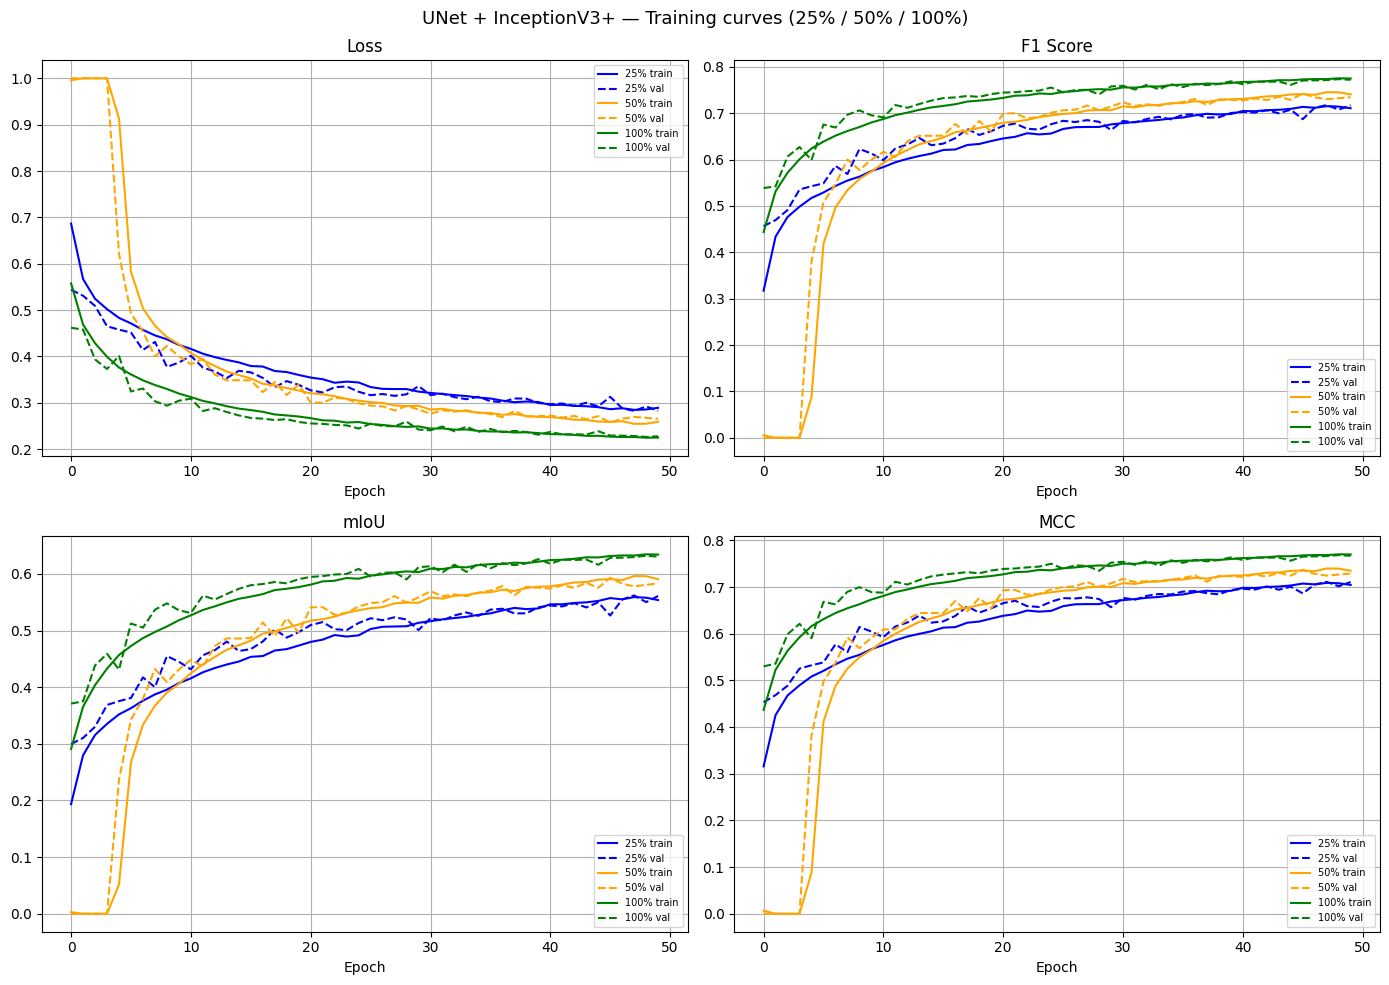

In [35]:
import matplotlib.pyplot as plt

all_histories = {'25%': history_25, '50%': history_50, '100%': history_100}
titles = ['Loss', 'F1 Score', 'mIoU', 'MCC']
keys   = [('train_loss','val_loss'), ('train_f1','val_f1'),
          ('train_miou','val_miou'), ('train_mcc','val_mcc')]
colors = {'25%':'blue', '50%':'orange', '100%':'green'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, title, (tk, vk) in zip(axes, titles, keys):
    for pct, hist in all_histories.items():
        c = colors[pct]
        ax.plot(hist[tk], color=c, linestyle='-',  label=f'{pct} train')
        ax.plot(hist[vk], color=c, linestyle='--', label=f'{pct} val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=7)
    ax.grid(True)

plt.suptitle('UNet + InceptionV3+ — Training curves (25% / 50% / 100%)', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import random

model_100.eval()

# Sample 8 random images from the test set
num_imgs = 8
test_dataset = test_loader_100.dataset
random_indices = random.sample(range(len(test_dataset)), num_imgs)

# Build batch manually
images_list, masks_list = [], []
for idx in random_indices:
    img, mask = test_dataset[idx]
    images_list.append(img)
    masks_list.append(mask)

images = torch.stack(images_list).to(device)
masks  = torch.stack(masks_list)

with torch.no_grad():
    outputs = model_100(images)
    preds = torch.sigmoid(outputs)
    preds = (preds > 0.5).float()

# Desnormalizar para visualizar
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(num_imgs, 3, figsize=(12, num_imgs * 4))

for i in range(num_imgs):
    img       = images[i].cpu() * std + mean
    img       = img.permute(1, 2, 0).clamp(0, 1)
    mask_real = masks[i].cpu().squeeze()
    mask_pred = preds[i].cpu().squeeze()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Original image (idx {random_indices[i]})")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_real, cmap="gray")
    axes[i, 1].set_title("Real mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(mask_pred, cmap="gray")
    axes[i, 2].set_title("Predicted mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

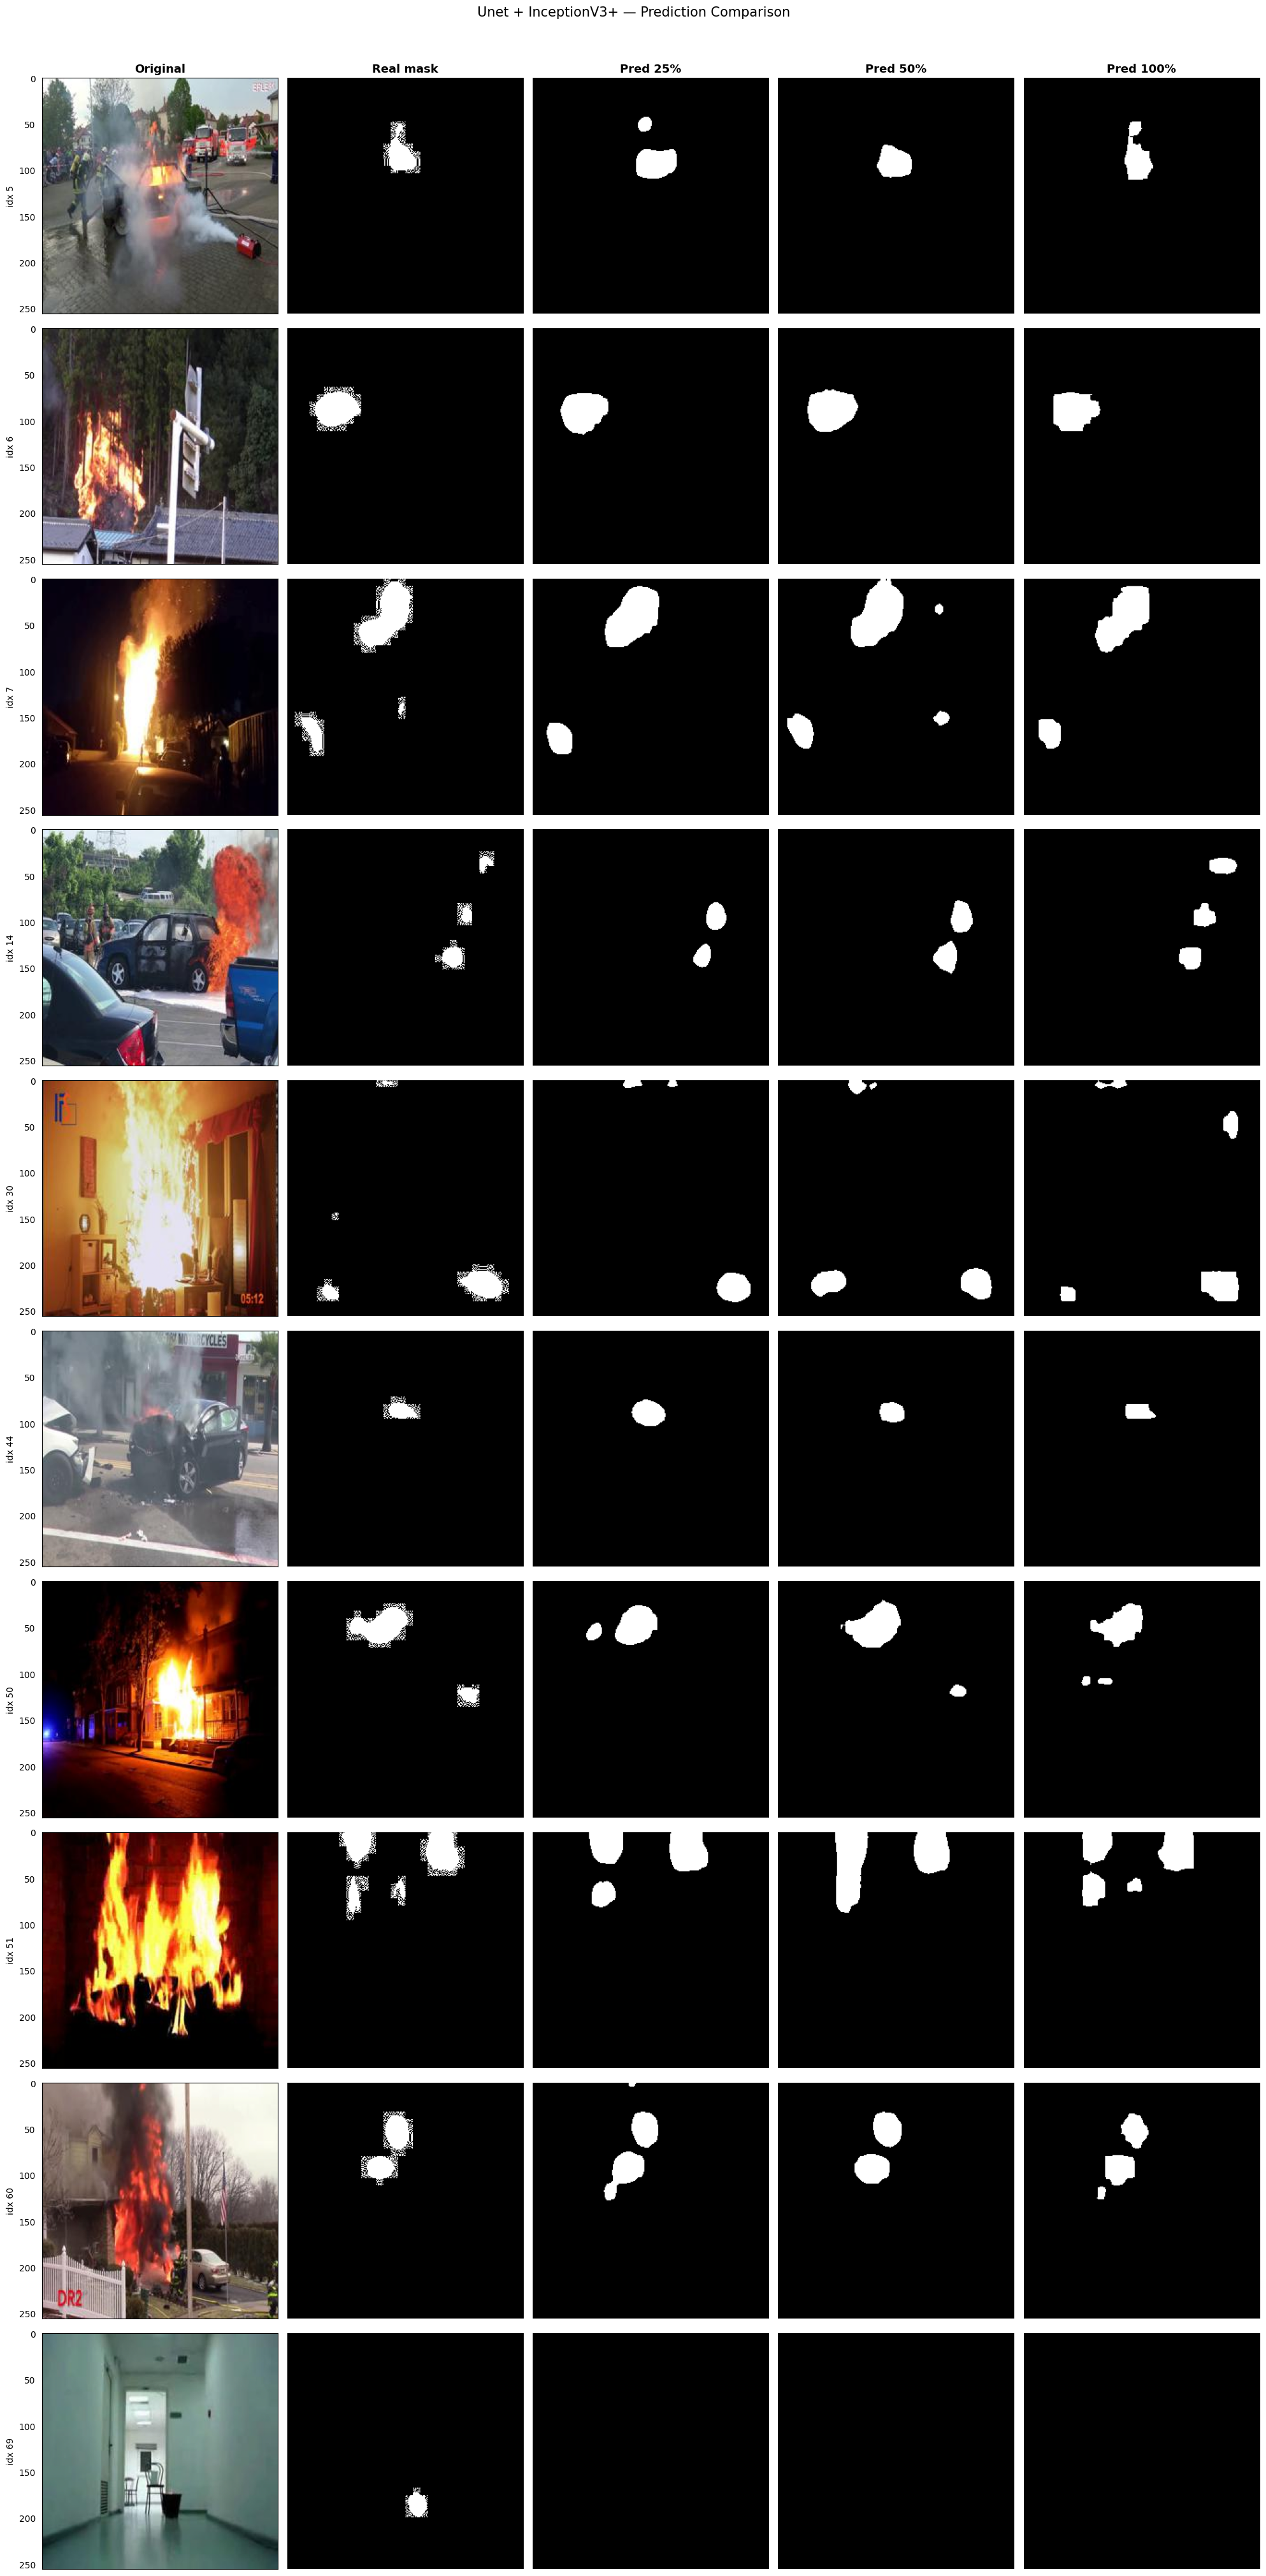

In [36]:
import matplotlib.pyplot as plt
import torch

fixed_indices = [5, 6, 7, 14, 30, 44, 50, 51, 60, 69]
num_imgs = len(fixed_indices)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def predict(model, dataset, indices):
    images_list, masks_list = [], []
    for idx in indices:
        img, mask = dataset[idx]
        images_list.append(img)
        masks_list.append(mask)
    images = torch.stack(images_list).to(device)
    masks  = torch.stack(masks_list)
    with torch.no_grad():
        outputs = model(images)
        preds   = torch.sigmoid(outputs)
        preds   = (preds > 0.5).float()
    return images, masks, preds

# Get predictions for the same fixed indices from all 3 models
test_dataset = test_loader_100.dataset

images, masks, preds_25  = predict(model_25,  test_dataset, fixed_indices)
_,      _,     preds_50  = predict(model_50,  test_dataset, fixed_indices)
_,      _,     preds_100 = predict(model_100, test_dataset, fixed_indices)

# Columns: Imagen | Mask real | Pred 25% | Pred 50% | Pred 100%
fig, axes = plt.subplots(num_imgs, 5, figsize=(20, num_imgs * 4))

col_titles = ["Original", "Real mask", "Pred 25%", "Pred 50%", "Pred 100%"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight="bold")

for i in range(num_imgs):
    img       = images[i].cpu() * std + mean
    img       = img.permute(1, 2, 0).clamp(0, 1)
    mask_real = masks[i].cpu().squeeze()
    pred_25   = preds_25[i].cpu().squeeze()
    pred_50   = preds_50[i].cpu().squeeze()
    pred_100  = preds_100[i].cpu().squeeze()

    axes[i, 0].imshow(img)
    axes[i, 0].set_ylabel(f"idx {fixed_indices[i]}", fontsize=10)

    axes[i, 1].imshow(mask_real, cmap="gray")
    axes[i, 2].imshow(pred_25,   cmap="gray")
    axes[i, 3].imshow(pred_50,   cmap="gray")
    axes[i, 4].imshow(pred_100,  cmap="gray")

    for col in range(5):
        axes[i, col].axis("off")
    axes[i, 0].axis("on")
    axes[i, 0].tick_params(left=False, bottom=False, labelleft=True, labelbottom=False)

plt.suptitle("Unet + InceptionV3+ — Prediction Comparison", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

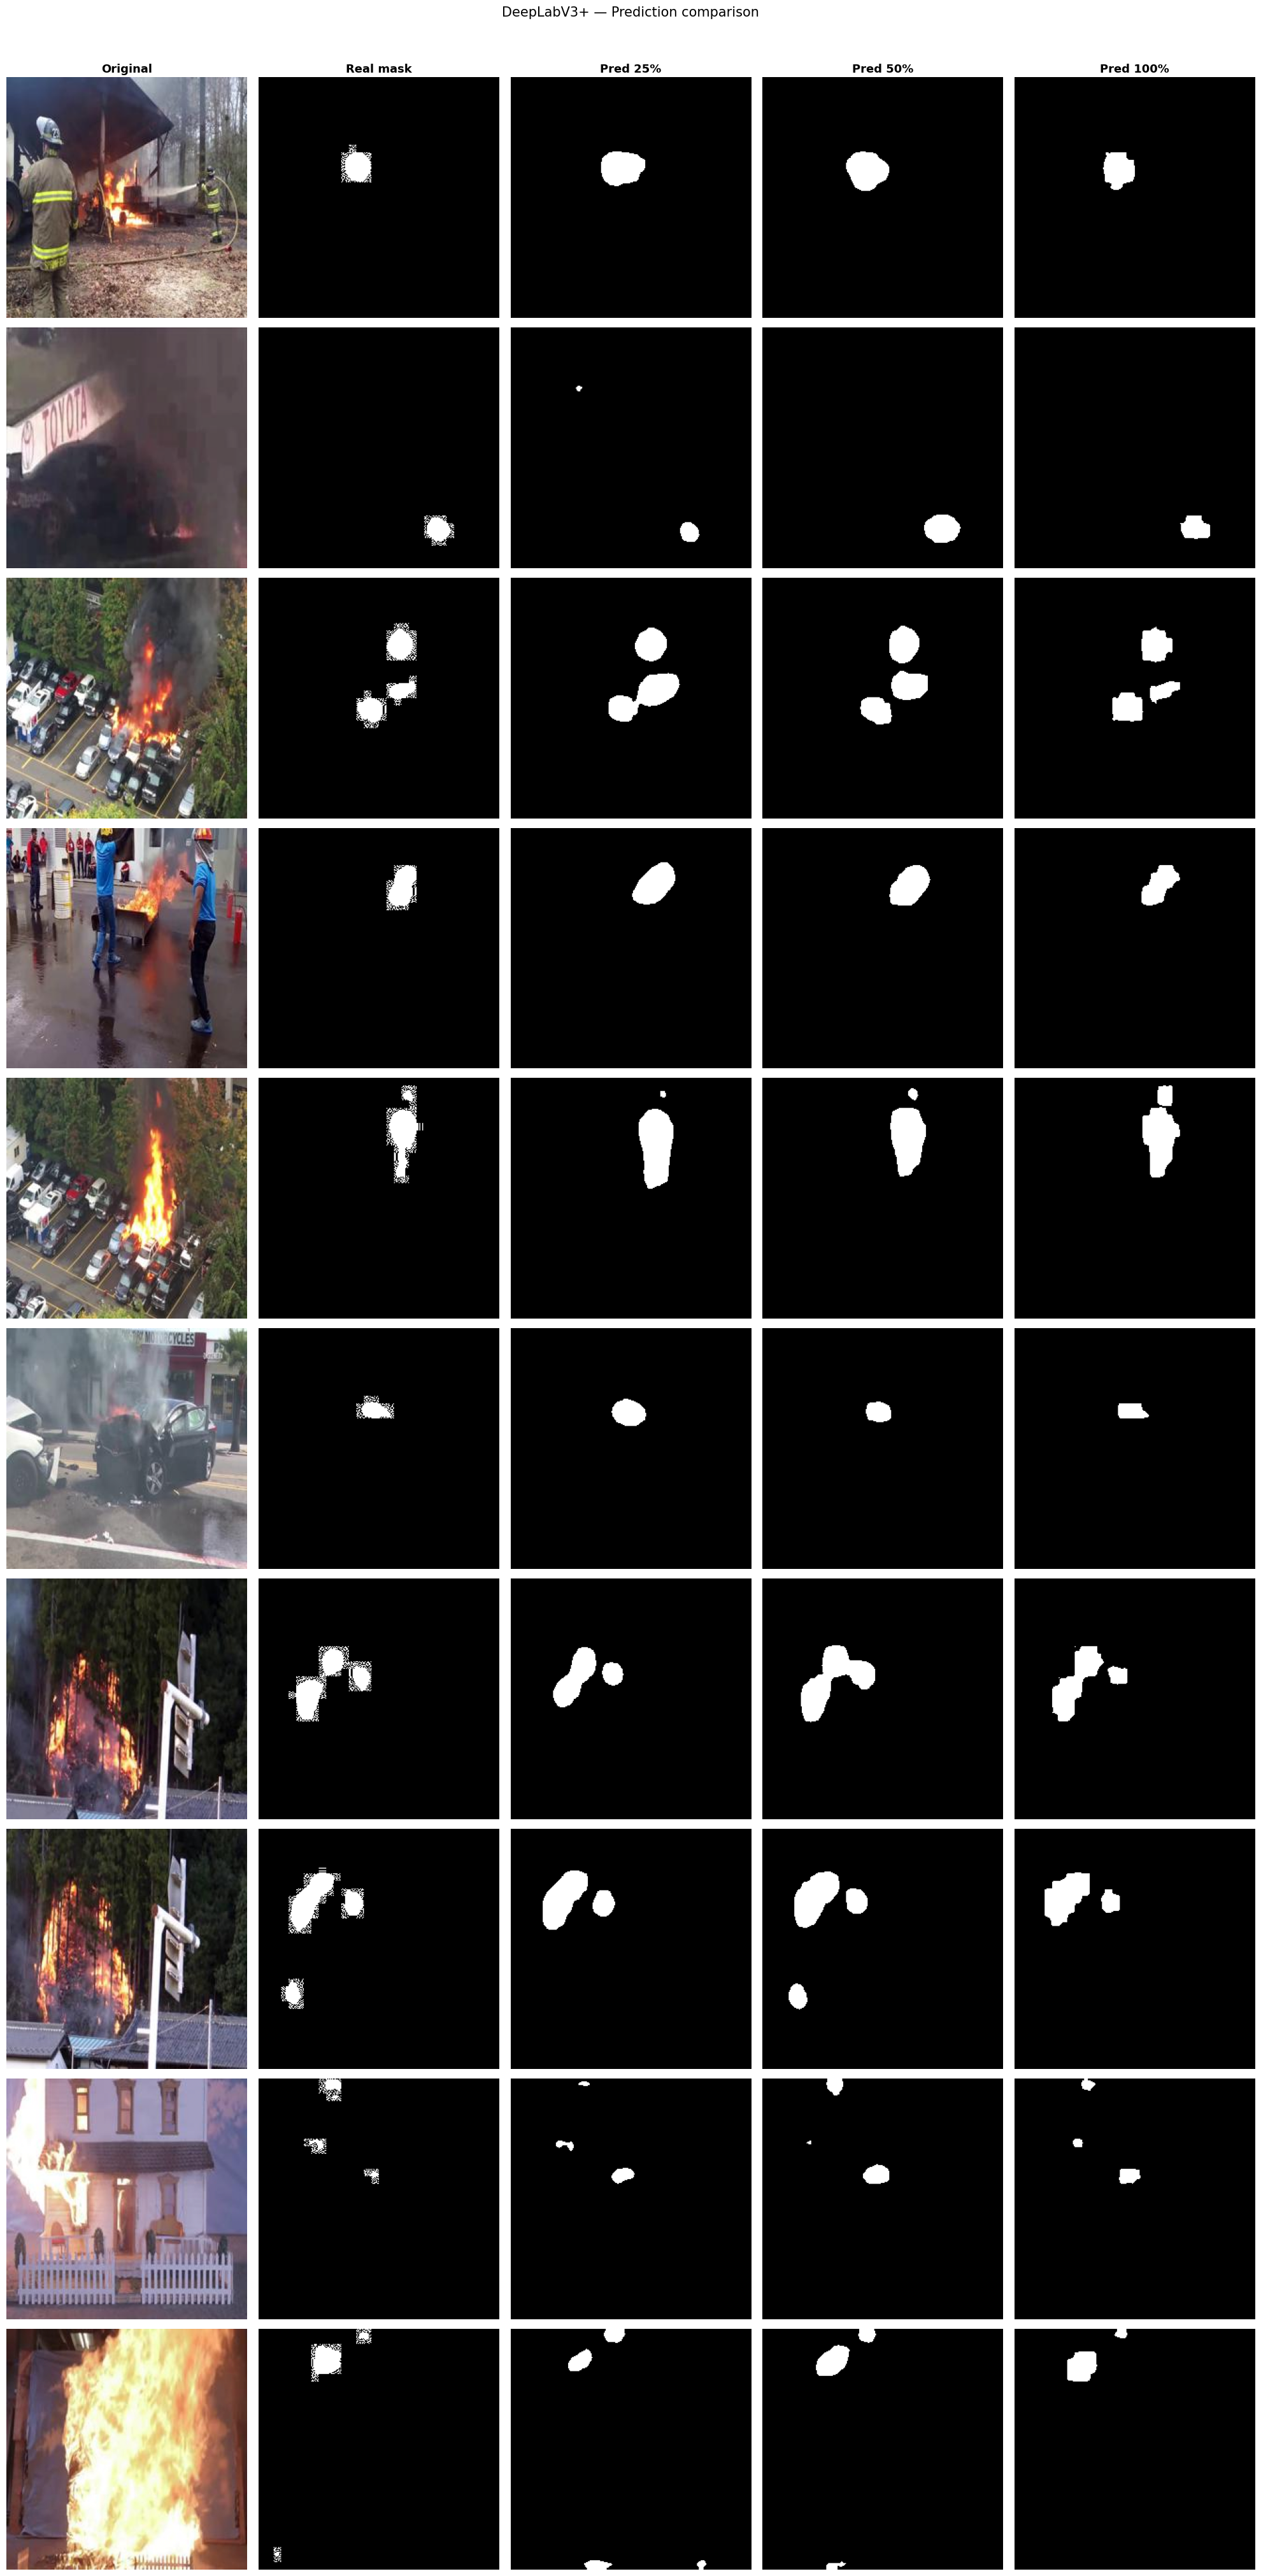

In [38]:
import matplotlib.pyplot as plt
import torch

target_names = [
    "Img_11183.jpg", "Img_16412.jpg", "Img_17795.jpg", "Img_15112.jpg",
    "Img_17166.jpg", "Img_18972.jpg", "Img_27865.jpg", "Img_27894.jpg",
    "Img_22772.jpg", "Img_23157.jpg"
]

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def find_indices_by_name(dataset, names):
    name_to_subset_idx = {}
    for subset_idx, real_idx in enumerate(dataset.indices):
        img_name = dataset.dataset.images[real_idx]
        if img_name in names:
            name_to_subset_idx[img_name] = subset_idx
    return [name_to_subset_idx[n] for n in names if n in name_to_subset_idx]

test_dataset  = test_loader_100.dataset
fixed_indices = find_indices_by_name(test_dataset, target_names)
num_imgs      = len(fixed_indices)

def predict(model, dataset, indices):
    images_list, masks_list = [], []
    for idx in indices:
        img, mask = dataset[idx]
        images_list.append(img)
        masks_list.append(mask)
    images = torch.stack(images_list).to(device)
    masks  = torch.stack(masks_list)
    with torch.no_grad():
        outputs = model(images)
        preds   = torch.sigmoid(outputs)
        preds   = (preds > 0.5).float()
    return images, masks, preds

images, masks, preds_25  = predict(model_25,  test_dataset, fixed_indices)
_,      _,     preds_50  = predict(model_50,  test_dataset, fixed_indices)
_,      _,     preds_100 = predict(model_100, test_dataset, fixed_indices)

fig, axes = plt.subplots(num_imgs, 5, figsize=(20, num_imgs * 4))

col_titles = ["Original", "Real mask", "Pred 25%", "Pred 50%", "Pred 100%"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight="bold")

for i in range(num_imgs):
    img       = images[i].cpu() * std + mean
    img       = img.permute(1, 2, 0).clamp(0, 1)
    mask_real = masks[i].cpu().squeeze()
    pred_25   = preds_25[i].cpu().squeeze()
    pred_50   = preds_50[i].cpu().squeeze()
    pred_100  = preds_100[i].cpu().squeeze()

    axes[i, 0].imshow(img)
    axes[i, 1].imshow(mask_real, cmap="gray")
    axes[i, 2].imshow(pred_25,   cmap="gray")
    axes[i, 3].imshow(pred_50,   cmap="gray")
    axes[i, 4].imshow(pred_100,  cmap="gray")

    for col in range(5):
        axes[i, col].axis("off")

plt.suptitle("DeepLabV3+ — Prediction comparison", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()